# Coefficient of Determination for Selection of Model Order in RFP Method

***

In our last notebook, we have seen that the essence of the Rational Fraction Polynomial (RFP) method is to fit the experimental Frequency Response Functions (FRF) of the measured DOFs with a rational function. This rational function is characterized by the order of the numerator and denominator polynomials, and we saw that we can apply a stabilization diagram approach to determine the order that results in an accurate estimation of the modal parameters. Similarly to what we did with the LSCE algorithm, for the stabilization criteria that we employed were frequency and damping ratio tolerances, and the Modal Assurance Criterion (MAC).

Since the RFP method represents a curve fitting problem (it fits the FRF directly in the frequency domain), we can also use a statistical approach to measure the goodness of fit of the estimated FRF and employ this measure as a stabilization criterion. More specifically, in this notebook we are going to see how we can use the coefficient of determination, also known as $R^2$, to measure the goodness of fit of the estimated FRF and use it as a stabilization criterion.

* [Theoretical Background](#theoretical-background)
* [Parameter Estimation from Random Excitation](#estimation-random)
    * [Data Generation and Processing](#data-generation-processing)
    * [Parameter Estimation with Fixed Model Order](#parameter-estimation-fixed)
    * [Parameter Estimation with Multiple Model Orders](#parameter-estimation-multiple)
* [Conclusions](#conclusions)

## Theoretical Background <a name="theoretical-background"></a>

***

In statistics, given the real-valued random variables $Y$ and $X$, and the model $f:\mathbb{R} \to \mathbb{R}$ that describes the relationship between $Y$ and $X$, the coefficient of determination is defined as the proportion of the variation in the dependent variable $Y$ that is predictable from the independent variable $X$. In mathematical terms, given a set of $n$ observations $(x_k, y_k)$, $k=1,\ldots,n$, the coefficient of determination is defined as:

$$
R^2 = 1 - \frac{\text{Unexplained variance}}{\text{Total variance}} =1 - \frac{\mathrm{E}\left(\left(Y - f(X)\right)^2\right)}{\mathrm{E}\left(\left(Y - \mu\right)^2\right)} = 1 - \frac{\frac{1}{n}\sum_{i=k}^n (y_k - f(x_k))^2}{\frac{1}{n}\sum_{i=1}^n (y_k - \bar{y})^2} = 1 - \frac{\sum_{i=k}^n (y_k - f(x_k))^2}{\sum_{i=1}^n (y_k - \bar{y})^2},
$$

where $\mathrm{E}$ is the expected value operator and $\bar{y}$ is the mean of the observed values $y_k$.

Another way to interpret the cofficient of determination, which is more relevant in the context of the RFP method, is given by the idea of [Gneiting & Resin (2023)](https://projecteuclid.org/journals/electronic-journal-of-statistics/volume-17/issue-2/Regression-diagnostics-meets-forecast-evaluation--conditional-calibration-reliability-diagrams/10.1214/23-EJS2180.full) to view it as a comparison between the performance of the employed model with that of a benchmark model:

$$
R^2 = 1 - \frac{\text{Performance of model}}{\text{Performance of benchmark model}}.
$$

In our case, the benchmark model is simply the mean of the observed values, which is a constant function and is also referred to as the "null model". The coefficient of determination is then a measure of how well the employed model (the RFP model in our case) performs compared to the null model in predicting the observed values. Typically, the coefficient of determination ranges between 0 and 1, but it can also be negative if the employed model performs worse than the null model. A value of 1 indicates that the employed model perfectly predicts the observed values, while a value of 0 indicates that the employed model does not improve the prediction compared to the null model.

The coefficient of determination can then be used as a stabilization criterion to select the order of the RFP model. The idea is to select a threshold value of $R^2$ and select the first order of the RFP model that results in a value of $R^2$ above this threshold. The threshold value can be selected based on the specific application and the desired level of accuracy.

However, the FRF is a complex-valued function, because it maps the frequency to a complex number. Therefore, we can't directly apply the above definition of $R^2$ to evaluate the overall goodness of fit of the FRF estimated by the RFP method. What we can do instead is to apply the above definition to the magnitude and phase of the FRF separately. In this way, we can obtain two different values of $R^2$, one for the magnitude, $R^2_\mathrm{mag}$, and for one for the phase, $R^2_\mathrm{phase}$. Applying this approach to $N$ measured DOFs, thus to $N$ measured FRFs, we will obtain $2N$ values of $R^2$.

How can we practically use these values to select the order of the RFP model within the stabilization diagram approach? We have mainly two options:
- keep the $2N$ values of $R^2$ separate and select the order of the RFP model where all the values of $R^2$ are above the threshold value. This is a conservative approach and it could be too restrictive in some cases;
- average $R^2_\mathrm{mag}$ and $R^2_\mathrm{phase}$ for each measured DOF and then average the resulting values across all the measured DOFs. Then select the order of the RFP model where the average value of $R^2$ is above the threshold value. It should be noted that this is not a rigorous approach, as there is no mathematical basis to average the $R^2$ values in this way, but it can be a practical approach to relax the condition of the first approach if it is too restrictive.

A more rigorous approach to calculate the coefficient of determination for the complex-valued FRF is to use the definition of variance for a complex-valued random variable $Y$ with expectation $\bar{y}$:

$$
\mathrm{var}(Y) = \mathrm{E}\left(\left(Y - \bar{y}\right)\left(Y - \bar{y}\right)^*\right),
$$

where $^*$ denotes the complex conjugate operator. In this case, the coefficient of determination can be defined as:

$$
R^2 = 1 - \frac{\sum_{i=k}^n \left(y_k - f(x_k)\right)\left(y_k - f(x_k)\right)^*}{\sum_{i=1}^n \left(y_k - \bar{y}\right)\left(y_k - \bar{y}\right)^*},
$$

where $y_k$ represents the complex value of the FRF for the $k$-th frequency point and $f(x_k)$ is the estimated value of the FRF at the same frequency point. This approach results in $N$ values of $R^2$ for the $N$ measured DOFs. Similarly to the previous approach, we can either keep the $N$ values of $R^2$ separate and select the order of the RFP model where all the values of $R^2$ are above the threshold value, or average the $N$ values of $R^2$ and select the order of the RFP model where the average value of $R^2$ is above the threshold value.

However, a more rigorous approach to calculate the coefficient of determination for $N$ complex-valued FRFs is to use the $l_2$-norm of the complex vectors $\boldsymbol{y_k} - \boldsymbol{f}(x_k)$ and $\boldsymbol{y_k} - \boldsymbol{\bar{y}}$, where $\boldsymbol{y_k}$ is the vector of the $k$-th complex values of the $N$ FRFs, $\left[y_{k,1},\ldots,y_{k,N}\right]^T$, and $\boldsymbol{f}(x_k)$ and $\boldsymbol{\bar{y}}$ are analogous complex vectors. The $l_2$-norm of a complex vector $\boldsymbol{x}$ is defined as:

$$
\|\boldsymbol{x}\|_2 = \sqrt{\sum_{j=1}^N x_jx_j^*}.
$$

The coefficient of determination for the estimated $N$ FRFs can then be defined as:

$$
R^2 = 1 - \frac{\sum_{k=1}^n\|\boldsymbol{y_k} - \boldsymbol{f}(x_k)\|_2^2}{\sum_{k=1}^n\|\boldsymbol{y_k} - \boldsymbol{\bar{y}}\|_2^2} = 1 - \frac{\sum_{k=1}^n\sum_{j=1}^N \left(y_{k,j} - f_j(x_k)\right)\left(y_{k,j} - f_j(x_k)\right)^*}{\sum_{k=1}^n\sum_{j=1}^N \left(y_{k,j} - \bar{y}_j\right)\left(y_{k,j} - \bar{y}_j\right)^*}
$$

We are now going to test these different approaches to calculate the coefficient of determination for the FRFs estimated by the RFP method.

## Parameter Estimation from Random Excitation <a name="estimation-random"></a>

***

### Data Generation and Processing <a name="data-generation-processing"></a>

In [1]:
from scipy import signal


def two_dof_mass_spring_damper(state, t, force):
    """
    Define system dynamics: dq/dt = f(q, t)

    Parameters:
    state (array): [displacement 1, displacement 2, velocity 1, velocity 2]
    t (float): Time
    force (function): External force signal, inputted as a function

    Returns:
    array: State derivatives [velocity 1, velocity 2, acceleration 1, acceleration 2]
    """

    # Unpack state variables
    x1, x2, x1dot, x2dot = state

    # Calculate accelerations based on the equation of motion
    x1ddot = (
        -(K[0, 0] * x1 + K[0, 1] * x2 + C[0, 0] * x1dot + C[0, 1] * x2dot) / M[0, 0]
    )
    x2ddot = (
        force(t)
        - (K[1, 0] * x1 + K[1, 1] * x2 + C[1, 0] * x1dot + C[1, 1] * x2dot) / M[1, 1]
    )

    # Return state derivatives
    return [x1dot, x2dot, x1ddot, x2ddot]


def calculate_h1_frf(
    input_signal, output_signal_array, fs, window="hann", nperseg=None, noverlap=None
):
    """
    Calculate the Frequency Response Function (FRF) with the H1 estimator and using SciPy's implementation of Welch's method.

    This function computes the H1 estimator: H1(f) = Gxy(f)/Gxx(f), where:
    - Gxy(f) is the cross-spectral density between input and output
    - Gxx(f) is the power spectral density of the input

    Parameters:
    -----------
    input_signal : array_like
        Input force signal
    output_signal_array : ndarray
        Array of output displacement signals with shape (n_outputs, n_samples)
    fs : float
        Sampling frequency of the signals
    window : str or tuple or array_like
        Window specification for the spectral estimation (default: 'hann')
    nperseg : int, optional
        Length of each segment (default: min(N, 256) where N is signal length)
    noverlap : int, optional
        Number of points to overlap between segments (default: nperseg//2)

    Returns:
    --------
    freqs : ndarray
        Array of sample frequencies
    frf : ndarray
        Array of FRFs for each output signal with shape (n_outputs, n_frequencies)
    """
    # Find number of output responses and initialize list of FRFs
    n_outputs = output_signal_array.shape[0]
    frfs = []

    # Process each output channel
    for i in range(n_outputs):
        # Calculate cross-spectral density between input and output
        # This gives us Gxy(f)
        f, Gxy = signal.csd(
            input_signal,
            output_signal_array[i],
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate power spectral density of the input
        # This gives us Gxx(f)
        _, Gxx = signal.welch(
            input_signal,
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate H1 estimator: H1(f) = Gxy(f)/Gxx(f)
        frf_channel = Gxy / Gxx
        frfs.append(frf_channel)

    # Return the frequencies and FRFs
    return f, np.array(frfs)


def plot_spectrum(
    frequencies, spectrum, unwrap=False, axes=None, label=None, title=None
):
    """Plot magnitude and phase spectrum of a signal

    Parameters:
    frequencies (array): Frequency vector of full spectrum (positive and negative frequencies)
    spectrum (array): Complex spectrum values
    unwrap (bool): Unwrap phase if True (optional)
    axes (array): Axes to plot on (optional)
    label (str): Label for the plot (optional)
    title (str): Plot title (optional)
    """
    # Get positive frequencies only (since spectrum is symmetric for real signals)
    pos_mask = frequencies >= 0
    pos_freqs = frequencies[pos_mask]
    pos_spectrum = spectrum[pos_mask]

    # Calculate magnitude in dB and phase in radians
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum))
    phase = np.angle(pos_spectrum)

    # Unwrap phase if specified
    if unwrap:
        phase = np.unwrap(phase)

    # Convert phase to degrees
    phase = np.rad2deg(phase)

    # Create figure with two subplots if axes are not provided
    if axes is None:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    else:
        fig = axes[0].figure

    # Plot magnitude
    axes[0].plot(pos_freqs, magnitude_db, label=label)
    axes[0].set_ylabel("Magnitude")
    axes[0].grid(True)

    # Plot phase
    axes[1].plot(pos_freqs, phase)
    axes[1].set_ylabel("Phase, deg")
    axes[1].set_xlabel("Frequency, Hz")
    axes[1].grid(True)

    # Set title if provided
    if title:
        axes[0].set_title(f"{title} Magnitude Spectrum")
        axes[1].set_title(f"{title} Phase Spectrum")

    # Return figure and axes for further customization if needed
    return fig, axes

In [2]:
import numpy as np


# Define number of degrees of freedom
N_DOFS = 2

# Define system parameters
m_1 = 6  # mass 1 [kg]
k_1 = 6000  # stiffness constant 1 [N/m]
m_2 = 4  # mass 2 [kg]
k_2 = 8000  # stiffness constant 2 [N/m]
alpha = 0  # mass matrix coefficient
beta = 0.001  # stiffness matrix coefficient

# Define system matrices
M = np.array([[m_1, 0], [0, m_2]])  # mass matrix
K = np.array([[k_1 + k_2, -k_2], [-k_2, k_2]])  # stiffness matrix
C = alpha * M + beta * K  # damping matrix

# Calculate natural frequencies by solving eigenvalue problem (K - omega^2 M) * a = 0
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(M) @ K)
reference_natural_frequencies = np.sqrt(eigenvalues)

# Mass normalize the eigenvectors
mass_normalized_modes = np.zeros_like(eigenvectors)
for i in range(N_DOFS):
    # Extract the i-th mode shape
    mode = np.atleast_2d(eigenvectors[:, i])

    # Calculate the modal mass (should be 1 after normalization)
    modal_mass = mode @ M @ mode.T

    # Calculate the scaling factor
    scaling_factor = 1 / np.sqrt(modal_mass)

    # Scale the mode shape
    mass_normalized_modes[:, i] = mode[0] * scaling_factor

# Find modal damping ratios
reference_damping_ratios = (
    1
    / (2 * reference_natural_frequencies)
    @ (mass_normalized_modes.T @ C @ mass_normalized_modes)
)

# Print results
print("Natural frequencies (rad/s):", reference_natural_frequencies)
print("Modal damping ratios:", reference_damping_ratios)
print("Mode shapes (mass normalized):")
print(mass_normalized_modes)

# Verify normalization (should give identity matrix)
print("Mass orthogonality check - Phi^T M Phi:")
print(mass_normalized_modes.T @ M @ mass_normalized_modes)

Natural frequencies (rad/s): [61.71015287 22.91703223]
Modal damping ratios: [0.03085508 0.01145852]
Mode shapes (mass normalized):
[[ 0.30297616  0.27362769]
 [-0.33512412  0.37106849]]
Mass orthogonality check - Phi^T M Phi:
[[1.00000000e+00 1.11022302e-16]
 [1.11022302e-16 1.00000000e+00]]


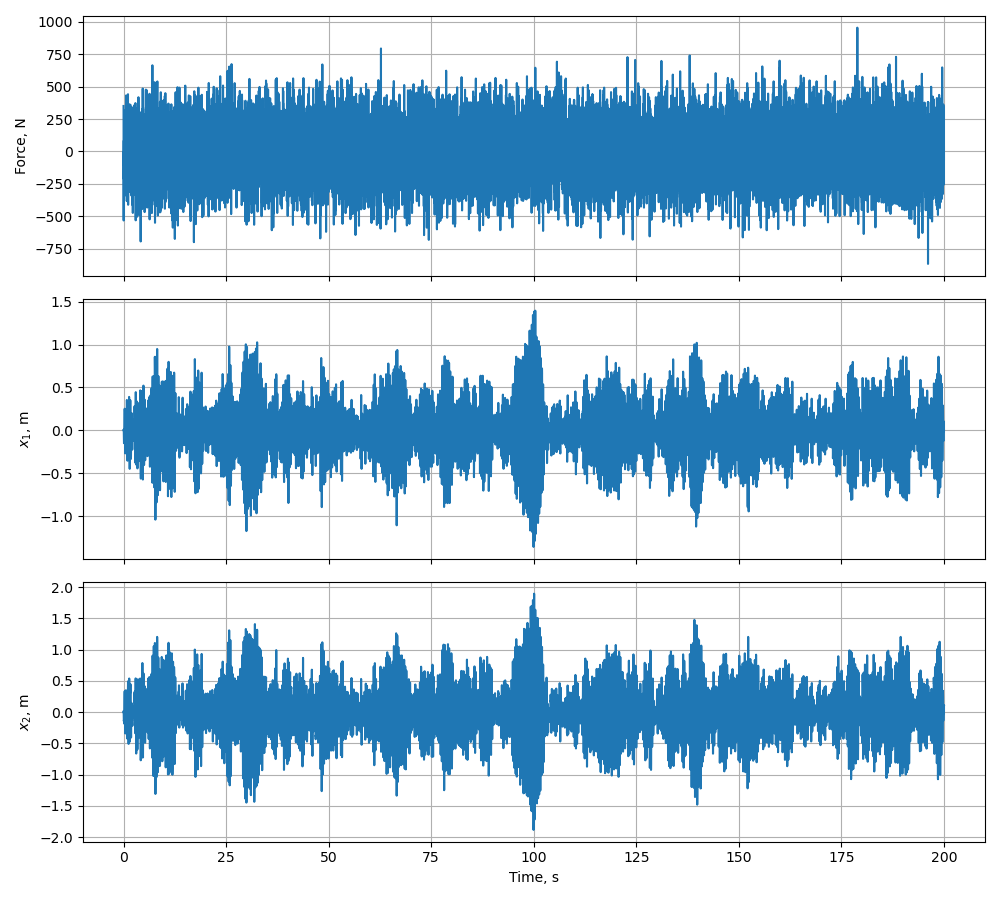

In [3]:
from scipy.interpolate import interp1d  # import interp1d function for interpolation
from scipy.integrate import odeint  # import odeint function for solving ODEs
import matplotlib.pyplot as plt  # import matplotlib library for plotting

# Enable interactive plots
%matplotlib widget

# Create time array
t_span = 200  # [s]
f_sampling = 100  # sampling frequency [Hz]
t_vector = np.arange(0, t_span, 1 / f_sampling)  # time vector [s]

# Generate random force signal
np.random.seed(11)  # set random seed for reproducibility
force_rms = 200  # RMS of the force signal [N]
random_signal = np.random.normal(
    size=len(t_vector)
)  # random signal with normal distribution centered at 0
random_force_signal = random_signal * (
    force_rms / np.sqrt(np.mean(random_signal**2))
)  # scale random signal to desired RMS [N]

# Create interpolated force function
random_force_function = interp1d(
    t_vector, random_force_signal, bounds_error=False, fill_value=0
)

# Solve ODE
initial_state = [0, 0, 0, 0]  # zero-displacement and zero-velocity initial conditions
solution = odeint(
    two_dof_mass_spring_damper, initial_state, t_vector, args=(random_force_function,)
)

# Extract displacements at the two degrees of freedom
displacements = solution[:, :2].T

# Create figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

# Plot force
random_force_signal = random_force_function(t_vector)
axes[0].plot(t_vector, random_force_signal)
axes[0].set_ylabel("Force, N")
axes[0].grid(True)

# Plot displacement
axes[1].plot(t_vector, displacements[0])
axes[1].set_ylabel("$x_1$, m")
axes[1].grid(True)

# Plot velocity
axes[2].plot(t_vector, displacements[1])
axes[2].set_ylabel("$x_2$, m")
axes[2].grid(True)
axes[2].set_xlabel("Time, s")

# Set layout and show plot
plt.tight_layout()
plt.show()

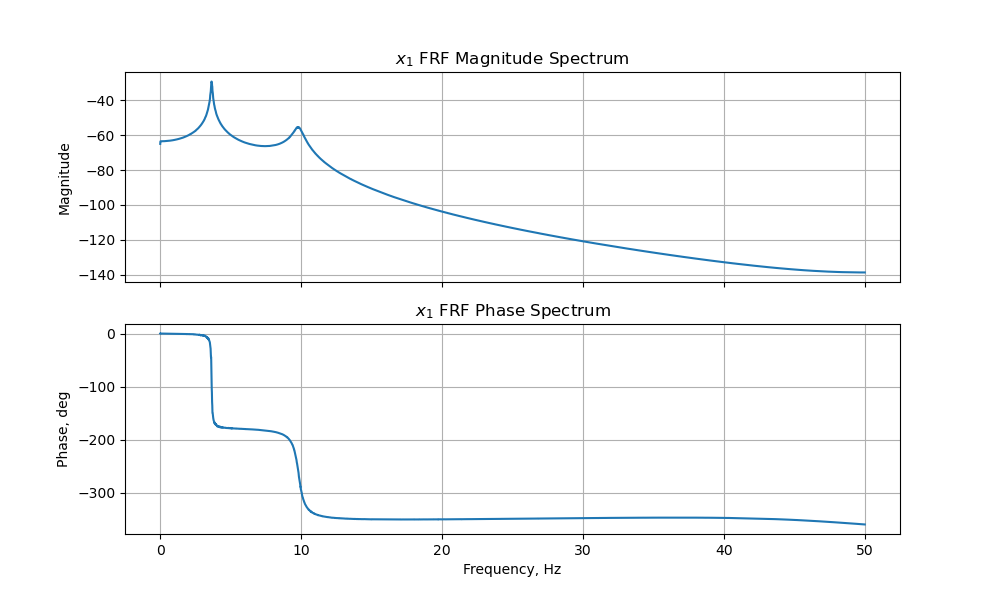

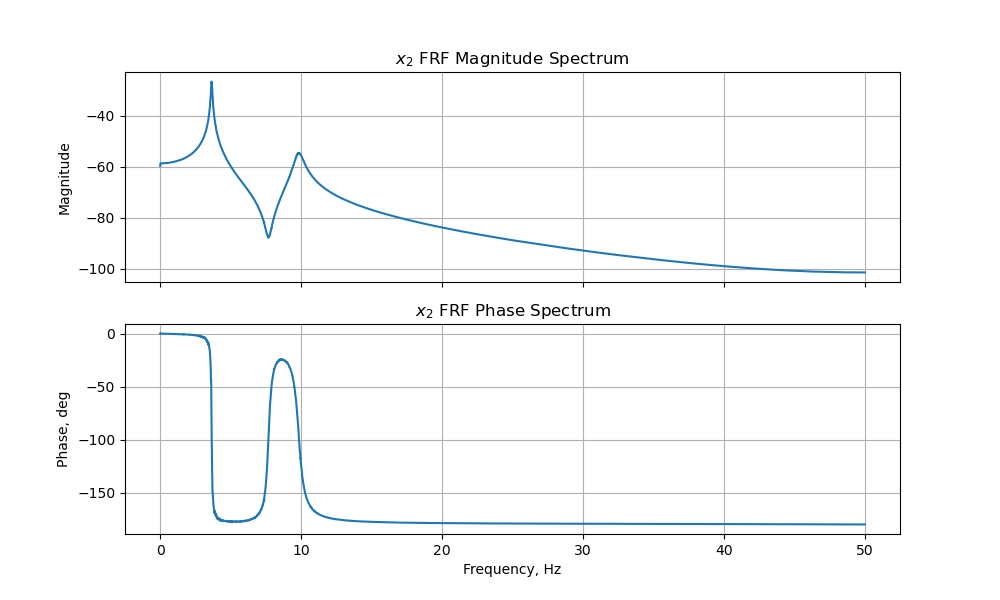

In [4]:
# Calculate improved FRF
frequencies, measured_frfs = calculate_h1_frf(
    random_force_signal, displacements, f_sampling, nperseg=7500
)

# Plot FRF spectrum for each degree of freedom
_, _ = plot_spectrum(frequencies, measured_frfs[0], unwrap=True, title="$x_1$ FRF")
plt.show()
_, _ = plot_spectrum(frequencies, measured_frfs[1], unwrap=True, title="$x_2$ FRF")
plt.show()

### Parameter Estimation with Fixed Model Order <a name="parameter-estimation-fixed"></a>

In [5]:
def generate_orthogonal_polynomials(omegas, order, weights):
    """
    Generate orthogonal polynomials using the Forsythe method and build the conversion matrix
    to map from orthogonal polynomial coefficients to ordinary polynomial coefficients.

    Parameters:
    omegas (array): Frequency points (real-valued)
    order (int): Maximum order of polynomials to generate
    weights (array): Weighting function values at each frequency point

    Returns:
    tuple: (
        complex_F: Complex orthogonal polynomials with shape (len(omegas), order+1),
        Gamma: Conversion matrix with shape (order+1, order+1) that maps from orthogonal
           to ordinary polynomial coefficients
    )
    """
    # Find number of frequency points
    n_frequencies = len(omegas)

    # Initialize array to store polynomials
    complex_F = np.zeros((n_frequencies, order + 1), dtype=complex)
    F = np.zeros((n_frequencies, order + 1), dtype=float)
    G = np.zeros((n_frequencies, order + 1), dtype=float)
    V = np.zeros(order + 1, dtype=float)

    # Initialize conversion matrix Gamma
    # Gamma[k,j] = coefficient of s^j in the k-th orthogonal polynomial
    Gamma = np.zeros((order + 1, order + 1))

    # coeff_arrays is a list of arrays, where each array represents one orthogonal polynomial in terms of powers of s
    # coeff_arrays[k] contains the coefficients of the k-th orthogonal polynomial φₖ(s)
    # coeff_arrays[k][j] holds the coefficient of s^j in the expansion of φₖ(s)
    coeff_arrays = [np.zeros(order + 1) for _ in range(order + 1)]

    # Calculate polynomials for k=0
    p0 = 1.0 / np.sqrt(np.sum(weights))  # coefficient for φ₀(s)
    F[:, 0] = p0  # for k=0 the orthogonal polynomial is constant
    complex_F[:, 0] = F[:, 0] * (1j**0)

    # Assign value of the coefficient of s^0 in φ₀(s)
    coeff_arrays[0][0] = p0
    Gamma[0, 0] = p0

    # Calculate polynomials for k=1
    G[:, 1] = omegas * F[:, 0]  # F[:,-1]=0, V[0]=0
    norm_factor = np.sqrt(np.sum(G[:, 1] ** 2 * weights))
    F[:, 1] = G[:, 1] / norm_factor
    complex_F[:, 1] = F[:, 1] * (1j**1)

    # For k=1, the orthogonal polynomial is p1*s
    p1 = p0 / norm_factor
    coeff_arrays[1][1] = p1  # coefficient of s^1 in φ₁(s)
    Gamma[1, 1] = p1

    # Iterate from k=2 to k=order
    for k in range(2, order + 1):
        # Calculate V[k-1]
        V[k - 1] = np.sum(omegas * F[:, k - 1] * F[:, k - 2] * weights)

        # Calculate G[:, k]
        G[:, k] = omegas * F[:, k - 1] - V[k - 1] * F[:, k - 2]

        # Calculate norm_factor
        norm_factor = np.sqrt(np.sum(G[:, k] ** 2 * weights))

        # Calculate F[:, k]
        F[:, k] = G[:, k] / norm_factor

        # Calculate complex polynomials
        complex_F[:, k] = F[:, k] * (1j**k)

        # Update coefficient arrays for this orthogonal polynomial
        # φₖ(s) = (s*φₖ₋₁(s) - V[k-1]*φₖ₋₂(s)) / norm_factor

        # First part: s*φₖ₋₁(s) -> shift coefficients up by one power of s
        temp_coeffs = np.zeros(
            order + 1
        )  # holds intermediate calculation before normalization
        for i in range(order):
            temp_coeffs[i + 1] = coeff_arrays[k - 1][i]

        # Second part: subtract V[k-1]*φₖ₋₂(s)
        for i in range(order + 1):
            temp_coeffs[i] -= V[k - 1] * coeff_arrays[k - 2][i]

        # Normalize
        coeff_arrays[k] = temp_coeffs / norm_factor

        # Update conversion matrix Gamma with these coefficients
        Gamma[k, :] = coeff_arrays[k]

    # Return the complex orthogonal polynomials and the conversion matrix
    return complex_F, Gamma


def grfp_curve_fit(frequencies, frfs, numerator_order, denominator_order):
    """
    Implements the Global Rational Fraction Polynomial (GRFP) method for curve fitting
    multiple FRF measurements simultaneously.

    Parameters:
    ----------
    frequencies : ndarray
        Array of frequency points (should be a set of symmetric frequencies around zero)
    frfs : ndarray
        Array of FRF measurements with shape (n_dofs, n_frequencies)
    numerator_order : int
        Order of the numerator polynomial
    denominator_order : int
        Order of the denominator polynomial

    Returns:
    -------
    tuple
        - a_coeffs: List of numerator ordinary polynomial coefficients for each DOF
        - b_coeffs: Denominator ordinary polynomial coefficients
    """
    # Find number of response FRFs and frequency points
    n_dofs = frfs.shape[0]
    n_freqs = frequencies.shape[0]

    # Create weights for polynomials
    # For numerator: uniform weighting
    numerator_weights = np.ones_like(frequencies)

    # For denominator: sum of squared magnitudes of all FRFs
    denominator_weights = np.sum(np.abs(frfs) ** 2, axis=0)

    # Generate numerator orthogonal polynomials
    phi, Gamma_numerator = generate_orthogonal_polynomials(
        frequencies, numerator_order, numerator_weights
    )

    # Generate denominator orthogonal polynomials
    theta, Gamma_denominator = generate_orthogonal_polynomials(
        frequencies, denominator_order, denominator_weights
    )

    # Setup matrices for the squared-error minimization problem
    D_T_list = []  # D_T,j matrices
    X_list = []  # X_j matrices
    H_list = []  # H_j vectors

    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Calculate T_j matrix
        T_j = (
            theta[:, :-1] * frfs[j][:, np.newaxis]
        )  # Broadcasting to create T_j matrix

        # Calculate D_T,j matrix
        D_T_j = np.diag(
            np.sum(np.abs(T_j) ** 2, axis=0)
        )  # Diagonal matrix of sum of squares along frequency points
        D_T_list.append(D_T_j)

        # Calculate X_j matrix
        X_j = -np.real(phi.conj().T @ T_j)
        X_list.append(X_j)

        # Calculate W_j vector
        W_j = frfs[j] * theta[:, -1]

        # Calculate H_j vector
        H_j = np.real(phi.conj().T @ W_j)
        H_list.append(H_j)

    # Calculate left and right-hand sides of the linear system for the denominator coefficients
    LHS = np.sum([D_Tj for D_Tj in D_T_list], axis=0) - np.sum(
        [X_j.T @ X_j for X_j in X_list], axis=0
    )
    RHS = -np.sum([X_j.T @ H_j for X_j, H_j in zip(X_list, H_list)], axis=0)

    # Solve for denominator coefficients d
    D = np.linalg.solve(LHS, RHS)

    # Add the last coefficient (d_n = 1)
    d_coeffs = np.append(D, 1)

    # Convert orthogonal denominator coefficients to ordinary denominator coefficients
    b_coeffs = np.zeros(denominator_order + 1, dtype=complex)
    for i in range(denominator_order + 1):
        b_coeffs[i] = np.sum(
            d_coeffs[i:]
            * Gamma_denominator[i:, i]
            * 1j ** (np.arange(denominator_order + 1 - i))
        )

    # Calculate numerator coefficients c_j for each DOF and convert to ordinary coefficients
    # Initialize lists for coefficients
    a_coeffs_list = []
    c_coeffs_list = []

    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Find orthogonal coefficients
        C_j = H_list[j] - X_list[j] @ D
        c_coeffs_list.append(C_j)

        # Convert orthogonal coefficients to ordinary coefficients
        a_coeffs_list.append(np.zeros(numerator_order + 1, dtype=complex))
        for i in range(numerator_order + 1):
            a_coeffs_list[j][i] = np.sum(
                c_coeffs_list[j][i:]
                * Gamma_numerator[i:, i]
                * 1j ** (np.arange(numerator_order + 1 - i))
            )

    # Return the coefficients and conversion matrices
    return a_coeffs_list, b_coeffs, c_coeffs_list, d_coeffs, phi, theta


def calculate_fitted_frf(angular_frequencies, a_coeffs_list, b_coeffs):
    """
    Calculate the fitted FRF using the polynomial coefficients.

    Parameters:
    ----------
    angular_frequencies : ndarray
        Array of angular frequencies (rad/s)
    a_coeffs_list : list
        List of numerator polynomial coefficients for each DOF
    b_coeffs : ndarray
        Denominator polynomial coefficients

    Returns:
    -------
    fitted_frf : ndarray
        Fitted FRF for each DOF
    """
    # Initialize arrray to store fitted FRFs
    fitted_frfs = np.zeros(
        (len(a_coeffs_list), len(angular_frequencies)), dtype=complex
    )

    # Loop through each degree of freedom to compare measured and fitted FRFs
    for j in range(N_DOFS):
        # Calculate fitted FRF using the polynomial coefficients
        fitted_frfs[j] = np.sum(
            [
                a_coeffs_list[j][k] * (angular_frequencies * 1j) ** k
                for k in np.arange(numerator_order + 1)
            ],
            axis=0,
        ) / np.sum(
            [
                b_coeffs[k] * (angular_frequencies * 1j) ** k
                for k in np.arange(denominator_order + 1)
            ],
            axis=0,
        )

    # Return the fitted FRFs
    return fitted_frfs

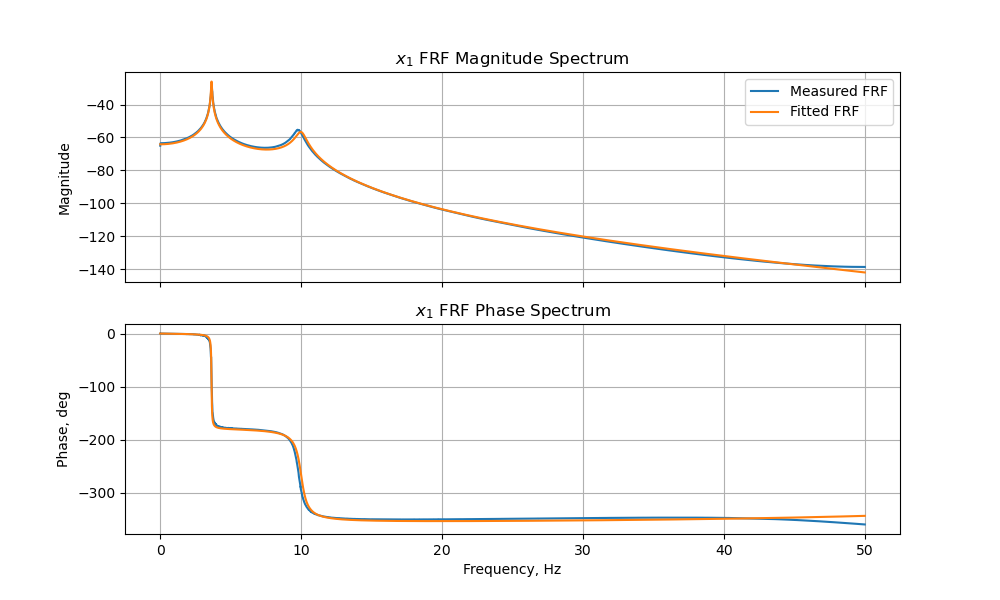

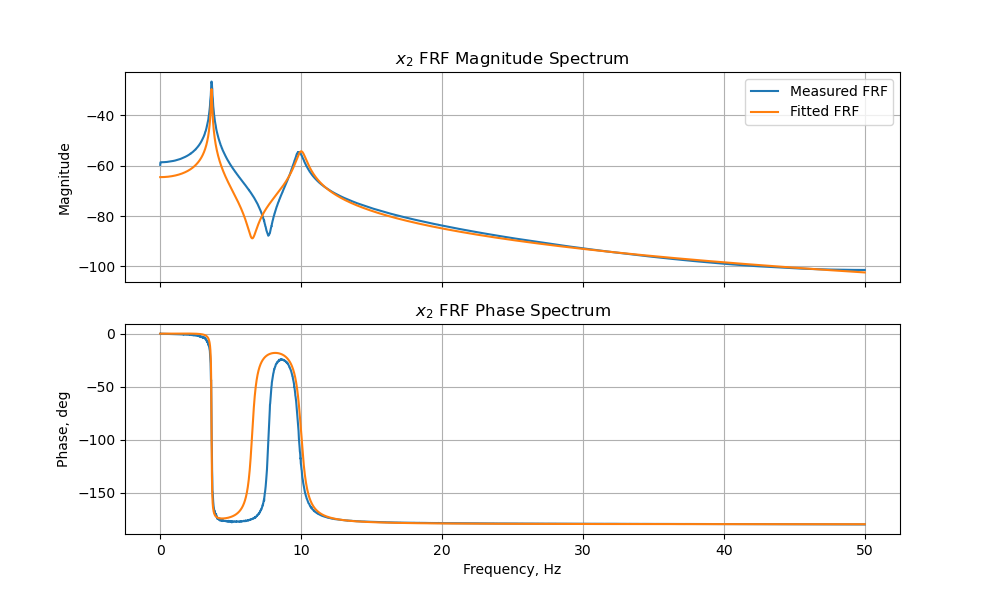

In [6]:
# Select numerator and denominator orders
numerator_order = 2
denominator_order = 4

# Take symmetric frequency points around zero (exclude Nyquist frequency point)
symmetric_mask = np.abs(frequencies) < f_sampling / 2
symmetric_angular_frequencies = 2 * np.pi * frequencies[symmetric_mask]

# Perform global curve fitting
a_coeffs_list, b_coeffs, _, _, _, _ = grfp_curve_fit(
    symmetric_angular_frequencies,
    measured_frfs[:, symmetric_mask],
    numerator_order,
    denominator_order,
)

# Calculate fitted FRFs
angular_frequencies = 2 * np.pi * frequencies
fitted_frfs = calculate_fitted_frf(angular_frequencies, a_coeffs_list, b_coeffs)

# Iterate through each DOF
for j in range(N_DOFS):

    # Plot measured FRF
    _, axes = plot_spectrum(
        frequencies,
        measured_frfs[j],
        unwrap=True,
        label="Measured FRF",
    )

    # Plot fitted FRF
    plot_spectrum(
        frequencies,
        fitted_frfs[j],
        unwrap=True,
        axes=axes,
        label="Fitted FRF",
        title=f"$x_{j+1:d}$ FRF",
    )

    # Add legend and show plot
    axes[0].legend()
    plt.show()

In [7]:
def calculate_r_squared_real_valued_function(observations, predictions):
    """
    Calculate the R-squared value for real-valued observations and predictions.

    Parameters:
    -----------
    observations : array_like
        Observed values (real-valued)
    predictions : array_like
        Predicted values (real-valued)

    Returns:
    --------
    float
        R-squared value (coefficient of determination)
    """
    # Calculate total sum of squares (SST)
    sst = np.sum((observations - np.mean(observations)) ** 2)

    # Calculate residual sum of squares (SSR)
    ssr = np.sum((observations - predictions) ** 2)

    # Calculate R-squared value
    r_squared = 1 - ssr / sst

    return r_squared


def calculate_r_squared_complex_valued_function(observations, predictions):
    """
    Calculate the R-squared value for complex-valued observations and predictions.

    Parameters:
    -----------
    observations : array_like
        Observed values (complex-valued)
    predictions : array_like
        Predicted values (complex-valued)

    Returns:
    --------
    float
        R-squared value (coefficient of determination)
    """
    # Calculate total sum of squares (SST)
    sst = np.sum(
        np.abs(observations - np.mean(observations)) ** 2
    )  # complex number multiplied by its conjugate gives the squared magnitude

    # Calculate residual sum of squares (SSR)
    ssr = np.sum(np.abs(observations - predictions) ** 2)

    # Calculate R-squared value
    r_squared = 1 - ssr / sst

    return r_squared


def calculate_r_squared_complex_valued_vectors(observations, predictions):
    """
    Calculate the R-squared value for complex-valued observations and predictions.

    Parameters:
    -----------
    observations : array_like
        Observed vectors (complex-valued) with shape (n_dofs, n_frequencies)
    predictions : array_like
        Predicted vectors (complex-valued) with shape (n_dofs, n_frequencies)

    Returns:
    --------
    float
        R-squared value (coefficient of determination)
    """
    # Calculate mean vectors of observations
    mean_observations = np.mean(observations, axis=1)

    # Calculate equivalent quantity to total sum of squares (SST)
    sst = np.sum(
        np.linalg.norm(
            observations
            - np.broadcast_to(mean_observations[:, np.newaxis], observations.shape),
            axis=0,
        )
        ** 2
    )

    # Calculate equivalent quantity to residual sum of squares (SSR)
    ssr = np.sum(np.linalg.norm(observations - predictions, axis=0) ** 2)

    # Calculate R-squared value
    r_squared = 1 - ssr / sst

    return r_squared

In [8]:
# Calculate R-squared values for the magnitude and phase of each fitted FRF
r_squared_magnitude = np.zeros(N_DOFS)
r_squared_phase = np.zeros(N_DOFS)
r_squared_average = np.zeros(N_DOFS)

positive_frequency_mask = frequencies >= 0  # mask for positive frequencies

for j in range(N_DOFS):
    # Calculate R-squared for magnitude
    r_squared_magnitude[j] = calculate_r_squared_real_valued_function(
        np.abs(measured_frfs[j][positive_frequency_mask]),
        np.abs(fitted_frfs[j][positive_frequency_mask]),
    )

    # Calculate R-squared for phase
    r_squared_phase[j] = calculate_r_squared_real_valued_function(
        np.unwrap(np.angle(measured_frfs[j][positive_frequency_mask])),
        np.unwrap(np.angle(fitted_frfs[j][positive_frequency_mask])),
    )

    # Calculate R-squared for average of magnitude and phase
    r_squared_average[j] = np.mean([r_squared_magnitude[j], r_squared_phase[j]])

    # Print results
    print(f"DOF {j+1}:")
    print(f"  R-squared magnitude: {r_squared_magnitude[j]:.2f}")
    print(f"  R-squared phase: {r_squared_phase[j]:.2f}")
    print(f"  R-squared average: {r_squared_average[j]:.2f}\n")

# Print R-squared averaged over all DOFs
print(f"R-squared averaged over all DOFs: {np.mean(r_squared_average):.2f}")

DOF 1:
  R-squared magnitude: 0.93
  R-squared phase: 1.00
  R-squared average: 0.97

DOF 2:
  R-squared magnitude: 0.78
  R-squared phase: 0.85
  R-squared average: 0.82

R-squared averaged over all DOFs: 0.89


In [9]:
# Calculate R-squared for each complex-valued FRF
r_squared_complex = np.zeros(N_DOFS)
for j in range(N_DOFS):
    r_squared_complex[j] = calculate_r_squared_complex_valued_function(
        measured_frfs[j][positive_frequency_mask],
        fitted_frfs[j][positive_frequency_mask],
    )
    print(f"DOF {j+1}: R-squared: {r_squared_complex[j]:.2f}")

# Print R-squared averaged over all DOFs
print(f"R-squared averaged over all DOFs: {np.mean(r_squared_complex):.2f}")

# Calculate R-squared for all complex-valued FRFs
r_squared_complex_all_frfs = calculate_r_squared_complex_valued_vectors(
    measured_frfs[:, positive_frequency_mask], fitted_frfs[:, positive_frequency_mask]
)
print(f"R-squared for all complex-valued FRFs: {r_squared_complex_all_frfs:.2f}")

DOF 1: R-squared: 0.88
DOF 2: R-squared: 0.77
R-squared averaged over all DOFs: 0.83
R-squared for all complex-valued FRFs: 0.81


### Parameter Estimation with Multiple Model Orders <a name="parameter-estimation-multiple"></a>

{'order': 4, 'r_squared_magnitude': array([0.65836989, 0.40594707]), 'r_squared_phase': array([0.86160517, 0.55988657]), 'r_squared_average': array([0.75998753, 0.48291682]), 'r_squared_average_all_dofs': np.float64(0.6214521741089056), 'r_squared_complex': array([0.52592749, 0.40590934]), 'r_squared_complex_all_dofs': np.float64(0.46591841690203967), 'r_squared_complex_vectors': np.float64(0.44841257745939056)}


{'order': 6, 'r_squared_magnitude': array([0.99861685, 0.99856023]), 'r_squared_phase': array([0.89721969, 0.99702378]), 'r_squared_average': array([0.94791827, 0.99779201]), 'r_squared_average_all_dofs': np.float64(0.9728551373580365), 'r_squared_complex': array([0.99517517, 0.99520732]), 'r_squared_complex_all_dofs': np.float64(0.9951912429300336), 'r_squared_complex_vectors': np.float64(0.9951959322364616)}


{'order': 8, 'r_squared_magnitude': array([0.92818622, 0.93219983]), 'r_squared_phase': array([-2.05856163,  0.41636721]), 'r_squared_average': array([-0.56518771,  0

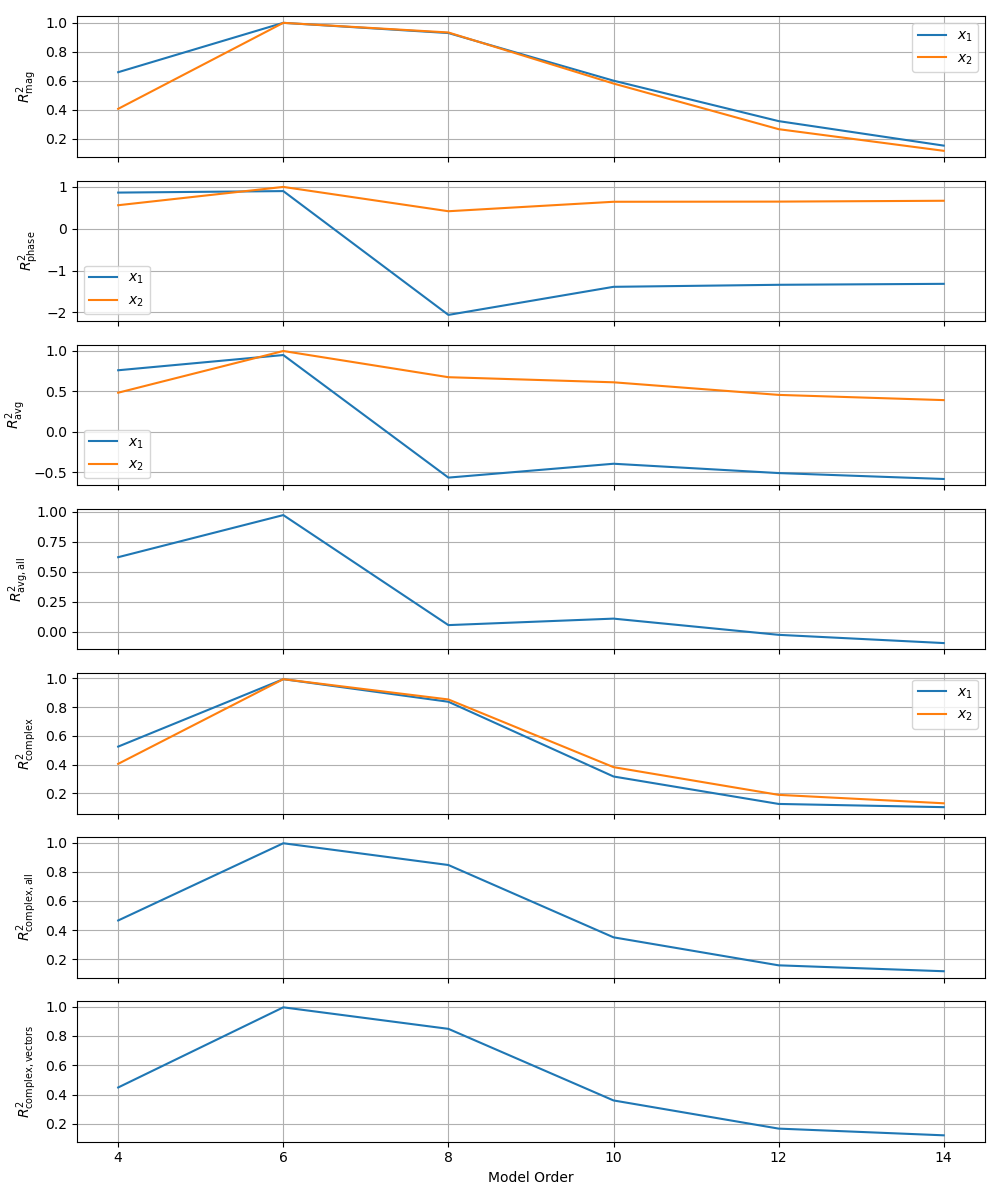

In [10]:
import pandas as pd


# Define order range for denominator polynomial
order_range = range(4, 16, 2)

# Initialize list of dictionaries to store modal parameters
r_squared_list = []

# Iterate over each order
for order in order_range:
    # Perform global curve fitting
    a_coeffs_list, b_coeffs, _, _, _, _ = grfp_curve_fit(
        symmetric_angular_frequencies, measured_frfs[:, symmetric_mask], order, order
    )

    # Initialize arrays to store R-squared values
    r_squared_magnitude = np.zeros(N_DOFS)
    r_squared_phase = np.zeros(N_DOFS)
    r_squared_average = np.zeros(N_DOFS)
    r_squared_complex = np.zeros(N_DOFS)

    # Iterate over each degree of freedom
    for j in range(N_DOFS):

        # Calculate fitted FRF using the polynomial coefficients
        fitted_frfs[j] = np.sum(
            [
                a_coeffs_list[j][k] * (angular_frequencies * 1j) ** k
                for k in np.arange(numerator_order + 1)
            ],
            axis=0,
        ) / np.sum(
            [
                b_coeffs[k] * (angular_frequencies * 1j) ** k
                for k in np.arange(denominator_order + 1)
            ],
            axis=0,
        )

        # Calculate R-squared for the fitted FRF
        r_squared_magnitude[j] = calculate_r_squared_real_valued_function(
            np.abs(measured_frfs[j][positive_frequency_mask]),
            np.abs(fitted_frfs[j][positive_frequency_mask]),
        )
        r_squared_phase[j] = calculate_r_squared_real_valued_function(
            np.unwrap(np.angle(measured_frfs[j][positive_frequency_mask])),
            np.unwrap(np.angle(fitted_frfs[j][positive_frequency_mask])),
        )
        r_squared_average[j] = np.mean([r_squared_magnitude[j], r_squared_phase[j]])
        r_squared_complex[j] = calculate_r_squared_complex_valued_function(
            measured_frfs[j][positive_frequency_mask],
            fitted_frfs[j][positive_frequency_mask],
        )

    # Calculate R-squared averaged over all DOFs
    r_squared_average_all_dofs = np.mean(r_squared_average)
    r_squared_complex_all_dofs = np.mean(r_squared_complex)
    r_squared_complex_vectors = calculate_r_squared_complex_valued_vectors(
        measured_frfs[:, positive_frequency_mask],
        fitted_frfs[:, positive_frequency_mask],
    )

    # Store modal parameters in dictionary
    result_dict = {
        "order": order,
        "r_squared_magnitude": r_squared_magnitude,
        "r_squared_phase": r_squared_phase,
        "r_squared_average": r_squared_average,
        "r_squared_average_all_dofs": r_squared_average_all_dofs,
        "r_squared_complex": r_squared_complex,
        "r_squared_complex_all_dofs": r_squared_complex_all_dofs,
        "r_squared_complex_vectors": r_squared_complex_vectors,
    }
    print(result_dict)
    print("\n")
    r_squared_list.append(result_dict)


# Convert list of dictionaries to DataFrame
r_squared_df = pd.DataFrame(r_squared_list)

# Set up figure to plot evolution of R-squared values with model order
fig, axes = plt.subplots(7, 1, figsize=(10, 12), sharex=True)
fig.subplots_adjust(hspace=0.5)
y_labels = [
    r"$R^2_\mathrm{mag}$",
    r"$R^2_\mathrm{phase}$",
    r"$R^2_\mathrm{avg}$",
    r"$R^2_\mathrm{avg, all}$",
    r"$R^2_\mathrm{complex}$",
    r"$R^2_\mathrm{complex, all}$",
    r"$R^2_\mathrm{complex, vectors}$",
]

# Iterate over each column in the DataFrame (excluding the first column "order")
for i, col in enumerate(r_squared_df.columns[1:], start=0):
    # Check if the first element is an array or scalar
    first_element = r_squared_df[col].iloc[0]

    if isinstance(first_element, np.ndarray):
        # If it's an array, plot separate line for each DOF
        for j in range(len(first_element)):
            axes[i].plot(
                r_squared_df["order"],
                [arr[j] for arr in r_squared_df[col]],
                label=f"$x_{j+1}$",
            )
        axes[i].legend()
    else:
        # If it's a scalar, plot directly
        axes[i].plot(r_squared_df["order"], r_squared_df[col])

    # Set y-label and grid
    axes[i].set_ylabel(y_labels[i])
    axes[i].grid(True)

# Set x-label for the last subplot
axes[-1].set_xlabel("Model Order")
plt.tight_layout()
plt.show()

Let's plot the fitted FRF for model order 6.

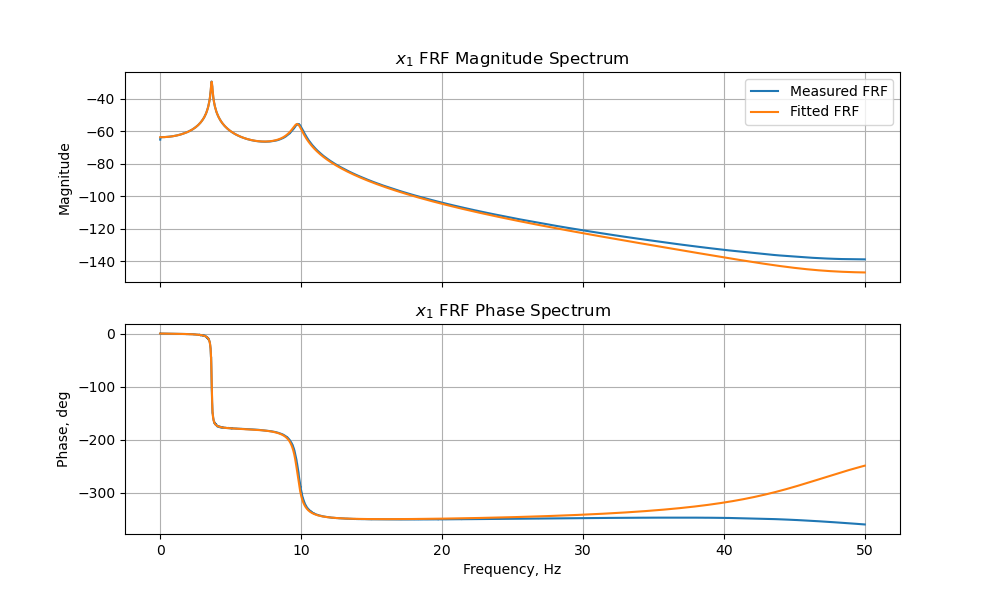

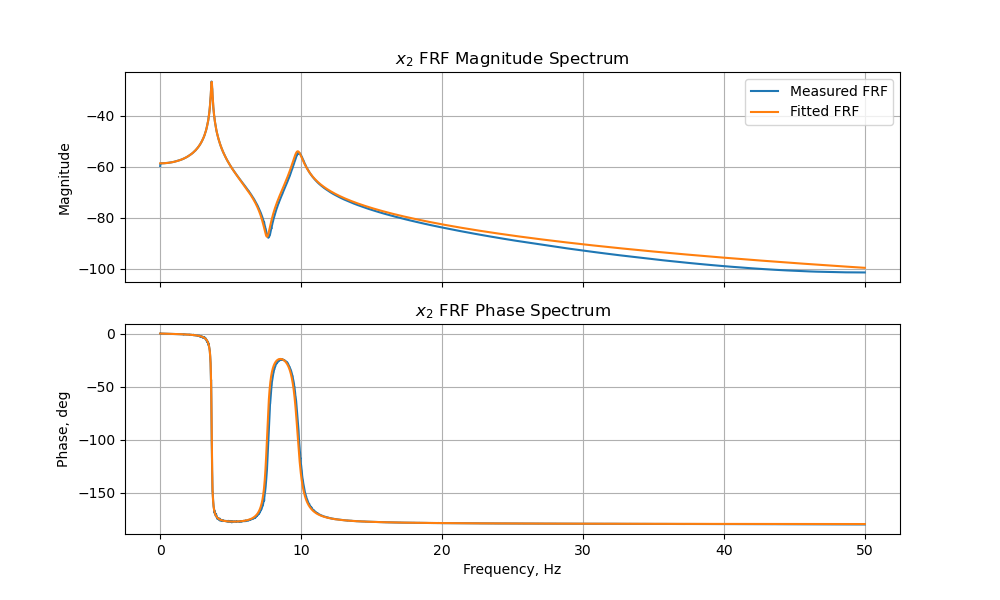

In [11]:
# Find polynomial coefficients for model order 6
model_order = 6
a_coeffs_list, b_coeffs, _, _, _, _ = grfp_curve_fit(
    symmetric_angular_frequencies,
    measured_frfs[:, symmetric_mask],
    model_order,
    model_order,
)

# Calculate fitted FRFs
fitted_frfs = calculate_fitted_frf(angular_frequencies, a_coeffs_list, b_coeffs)

# Plot original and fitted FRFs
for j in range(N_DOFS):
    _, axes = plot_spectrum(
        frequencies,
        measured_frfs[j],
        unwrap=True,
        label="Measured FRF",
    )
    plot_spectrum(
        frequencies,
        fitted_frfs[j],
        unwrap=True,
        axes=axes,
        label="Fitted FRF",
        title=f"$x_{j+1:d}$ FRF",
    )

    # Add legend and show plot
    axes[0].legend()
    plt.show()

Calculate modal parameters and compare with the true values.

In [12]:
# Get default matlpotlib colors
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def extract_poles(b_coeffs):
    """
    Extract poles from the denominator polynomial coefficients.

    Parameters:
    ----------
    b_coeffs : ndarray
        Denominator ordinary polynomial coefficients

    Returns:
    -------
    tuple:
        - natural_freqs: array of natural frequencies (rad/s) of size (n_modes,)
        - damping_ratios: array of damping ratios of size (n_modes,)
        - pole_pairs: array of complex conjugate pole pairs of size (n_modes, 2)
    """
    # Find roots of the denominator polynomial
    lambdas = np.roots(b_coeffs[::-1])

    # Initialize array of pole pairs, natural frequencies, and damping ratios
    n_modes = len(lambdas) // 2
    pole_pairs = np.zeros((n_modes, 2), dtype=complex)
    natural_freqs = np.zeros(n_modes, dtype=float)
    damping_ratios = np.zeros(n_modes, dtype=float)

    # Process poles to find complex conjugate pairs
    remaining_poles = lambdas.copy()
    i = 0
    while len(remaining_poles) > 0:
        # Take the first pole as the reference pole
        p = remaining_poles[0]

        # Calculate square root distance to other poles
        distances = np.sqrt(
            (remaining_poles[1:].real - p.real) ** 2
            + (remaining_poles[1:].imag + p.imag) ** 2
        )

        # Find the closest pole
        closest_idx = np.argmin(distances) + 1
        closest_pole = remaining_poles[closest_idx]

        # Store the pole pair
        pole_pairs[i] = np.array([p, closest_pole])

        # Calculate natural frequency
        natural_freqs[i] = np.abs(p)

        # Calculate damping ratio
        damping_ratios[i] = -p.real / natural_freqs[i]

        # Remove the processed poles from the list and update the index
        remaining_poles = np.delete(remaining_poles, [0, closest_idx])
        i += 1

    # Sort arrays by natural frequency (ascending)
    sort_indices = np.argsort(natural_freqs)
    pole_pairs = pole_pairs[sort_indices]
    natural_freqs = natural_freqs[sort_indices]
    damping_ratios = damping_ratios[sort_indices]

    # Return results
    return natural_freqs, damping_ratios, pole_pairs


def calculate_modes(a_coeffs_list, pole_pairs, drive_index=1):
    """
    Calculate mode shapes from the numerator coefficients and poles.

    Parameters:
    ----------
    a_coeffs_list : list
        List of numerator ordinary polynomial coefficients for each DOF
    pole_pairs : ndarray
        Array of complex conjugate pole pairs of size (n_modes, 2)
    drive_index : int
        Index of the driving point (default: 1 for second DOF)

    Returns:
    -------
    tuple:
        - residues: Residues for each DOF and mode
        - modes: Mode shapes (normalized)
    """
    # Find number of degrees of freedom and modes
    n_dofs = len(a_coeffs_list)
    n_modes = pole_pairs.shape[0]

    # Find numerator polynomial order
    numerator_order = len(a_coeffs_list[0]) - 1

    # Initialize arrays for residues and mode shapes
    residues = np.zeros((n_dofs, n_modes), dtype=complex)
    modes = np.zeros((n_dofs, n_modes))

    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Calculate residues for each mode
        for i in range(n_modes):
            poles = pole_pairs[i]
            remaining_poles = np.delete(pole_pairs, i, axis=0)
            residues[j, i] = np.sum(
                a_coeffs_list[j] * poles[0] ** np.arange(numerator_order + 1)
            ) / (
                (poles[0] - poles[1])
                * np.prod(
                    (poles[0] - remaining_poles[:, 0])
                    * (poles[0] - remaining_poles[:, 1])
                )
            )

    # Use the driving point residues to normalize mode shapes
    # Scale factor is square root of driving point residues
    # v_jr = R_jr / sqrt(R_2r)
    scale_factors = np.sqrt(residues[drive_index, :])

    # Iterate over each degree of freedom
    for j in range(n_dofs):
        # Calculate ratios of residues to scale factors
        ratios = residues[j, :] / scale_factors
        # Extract every second element (since poles are complex conjugate pairs) and take the real part
        modes[j, :] = ratios.real

    # Normalize mode shapes to unit length
    norms = np.linalg.norm(modes, axis=0)
    modes /= norms

    # Return the mode shapes
    return modes


def plot_mode_shapes(true_modes, est_modes):
    """
    Plot true vs estimated mode shapes

    Parameters:
    true_modes: array of shape (number of DOFs, number of modes) containing true mode shapes
    est_modes: array of shape (number of DOFs, number of modes) containing estimated mode shapes
    """
    # Create x-axis vector with node positions (x1, x2)
    node_positions = np.arange(1, N_DOFS + 1)

    # Define offset for estimated mode shapes
    offset = 0.03

    # Create a figure with a subplot for each mode
    n_modes = true_modes.shape[1]
    fig, axes = plt.subplots(n_modes, 1, figsize=(5, 3 * n_modes), sharex=True)

    # Iterate over each mode
    for i in range(n_modes):
        # Ensure mode shapes are oriented in the same direction
        if np.dot(true_modes[:, i], est_modes[:, i]) < 0:
            est_modes[:, i] = -est_modes[:, i]

        # Iterate over each degree of freedom
        for j in range(N_DOFS):
            # Plot component of current degree of freedom for current mode shape
            true_line = axes[i].plot(
                np.array([j + 1, j + 1]) - offset,
                [0, true_modes[j, i]],
                color=COLORS[0],
                label="True Mode Shape",
                linewidth=2,
            )
            est_line = axes[i].plot(
                np.array([j + 1, j + 1]) + offset,
                [0, est_modes[j, i]],
                color=COLORS[1],
                label="Estimated Mode Shape",
                linewidth=2,
            )

            # Plot markers
            axes[i].scatter(
                (j + 1) - offset,
                true_modes[j, i],
                color=COLORS[0],
                marker="o",
                s=100,
                zorder=5,
            )
            axes[i].scatter(
                (j + 1) + offset,
                est_modes[j, i],
                color=COLORS[1],
                marker="x",
                s=100,
                zorder=5,
            )

        # Add labels and legend
        axes[i].set_title(f"Mode {i+1}")
        axes[i].set_ylabel("Amplitude")
        axes[i].grid(True)

    # Add labels and legend
    axes[0].legend(
        [true_line[0], est_line[0]], ["True Mode Shape", "Estimated Mode Shape"]
    )
    axes[-1].set_xlabel("DOF")
    axes[-1].set_xticks(node_positions)
    axes[-1].set_xticklabels([f"$x_{i+1}$" for i in range(N_DOFS)])

    # Set layout and show plot
    plt.tight_layout()
    plt.show()

Mode 1
True natural frequency: 22.92 rad/s
Estimated natural frequency: 22.92 rad/s
Percentage error: -0.00%
True damping ratio: 0.01
Estimated damping ratio: 0.01
Percentage error: -1.51%

Mode 2
True natural frequency: 61.71 rad/s
Estimated natural frequency: 61.71 rad/s
Percentage error: -0.00%
True damping ratio: 0.03
Estimated damping ratio: 0.03
Percentage error: 0.02%



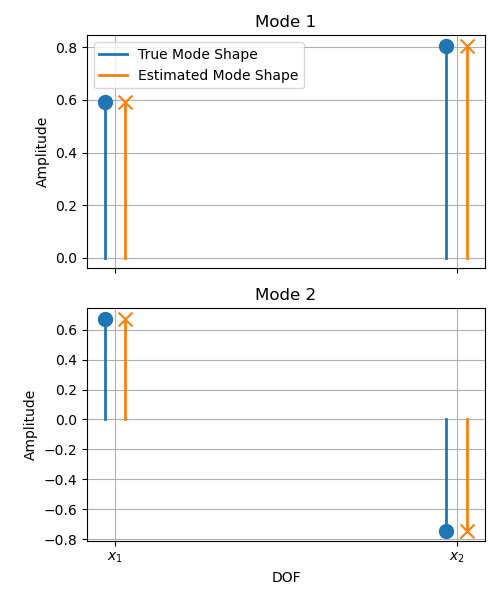

In [13]:
# Estimate modal parameters from denominator coefficients
estimated_natural_frequencies, estimated_damping_ratios, pole_pairs = extract_poles(
    b_coeffs
)

# Take sorted true natural frequencies and damping ratiosn for comparison
sort_indices = np.argsort(reference_natural_frequencies)
reference_natural_frequencies_sorted = reference_natural_frequencies[sort_indices]
reference_damping_ratios_sorted = reference_damping_ratios[sort_indices]

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(N_DOFS):
    print(f"Mode {i+1:d}")
    print(
        f"True natural frequency: {reference_natural_frequencies_sorted[i]:.2f} rad/s"
    )
    print(f"Estimated natural frequency: {estimated_natural_frequencies[i]:.2f} rad/s")
    print(
        f"Percentage error: {100 * (estimated_natural_frequencies[i]/reference_natural_frequencies_sorted[i] - 1):.2f}%"
    )
    print(f"True damping ratio: {reference_damping_ratios_sorted[i]:.2f}")
    print(f"Estimated damping ratio: {estimated_damping_ratios[i]:.2f}")
    print(
        f"Percentage error: {100 * (estimated_damping_ratios[i]/reference_damping_ratios_sorted[i] - 1):.2f}%\n"
    )

# Calculate estimated mode shapes
estimated_modes = calculate_modes(a_coeffs_list, pole_pairs)

# Sort true mode shapes based on true natural frequencies
reference_modes_sorted = np.zeros_like(eigenvectors)
for i in range(N_DOFS):
    reference_modes_sorted[:, i] = eigenvectors[:, sort_indices[i]]

# Plot true vs estimated mode shapes
plot_mode_shapes(reference_modes_sorted, estimated_modes)